### 1. Simulate Sales Data using NumPy:
   - Create arrays for 100 sales transactions:
     - product_ids: Random integers from 1001 to 1010
     - quantities: Random integers between 1 and 5
     - prices: Random floats between 10 and 100 (rounded to 2 decimals)
     - dates: 100 random dates between Jan 1 and Jan 10, 2025

In [2]:
import numpy as np

np.random.seed(1)

product_ids=np.random.randint(1001,1011,size=100)
quantities=np.random.randint(1,6,size=100)
prices=np.round(np.random.uniform(10,101,size=100),2)

start_date=np.datetime64("2025-01-01")
end_date=np.datetime64("2025-01-11")

dates=np.random.randint(
    start_date.astype("int64"),
    end_date.astype("int64"),
    size=100
).astype("datetime64[D]")

### 2. Create a DataFrame using Pandas:
   - Combine the arrays into a DataFrame called sales_df with columns:
     - ProductID, Quantity, Price, Date

In [3]:
import pandas as pd

sales_df=pd.DataFrame({
    "ProductID":product_ids,
    "Quantity":quantities,
    "Price":prices,
    "Date":dates
})
print(sales_df)

    ProductID  Quantity  Price       Date
0        1006         2  32.96 2025-01-05
1        1009         1  77.69 2025-01-01
2        1010         5  27.78 2025-01-09
3        1006         3  62.90 2025-01-03
4        1001         1  98.27 2025-01-04
..        ...       ...    ...        ...
95       1005         2  93.59 2025-01-09
96       1005         3  10.04 2025-01-06
97       1008         5  98.89 2025-01-04
98       1008         5  44.27 2025-01-02
99       1005         4  98.61 2025-01-05

[100 rows x 4 columns]


### 3. Add Total Sale Column:
   - Create a new column: TotalSale = Quantity * Price

In [5]:
sales_df["TotalSale"]=sales_df["Quantity"]*sales_df["Price"]
print(sales_df)

    ProductID  Quantity  Price       Date  TotalSale
0        1006         2  32.96 2025-01-05      65.92
1        1009         1  77.69 2025-01-01      77.69
2        1010         5  27.78 2025-01-09     138.90
3        1006         3  62.90 2025-01-03     188.70
4        1001         1  98.27 2025-01-04      98.27
..        ...       ...    ...        ...        ...
95       1005         2  93.59 2025-01-09     187.18
96       1005         3  10.04 2025-01-06      30.12
97       1008         5  98.89 2025-01-04     494.45
98       1008         5  44.27 2025-01-02     221.35
99       1005         4  98.61 2025-01-05     394.44

[100 rows x 5 columns]


### 4. Introduce Missing Data:
   - Randomly set 5 Price values to NaN
   - Fill missing prices with the mean price

In [83]:
np.random.seed(1)
missing_indices=np.random.choice(sales_df.index,size=5,replace=False)
sales_df.loc[missing_indices,"Price"]=np.nan
mean_price=sales_df["Price"].mean()
sales_df.fillna({"Price":np.round(mean_price,2)},inplace=True)

,ProductID,Quantity,Price,Date,TotalSale
0,1006,2,32.96,2025-01-05,65.92
1,1009,1,77.69,2025-01-01,77.69
2,1010,5,27.78,2025-01-09,138.90
3,1006,3,62.90,2025-01-03,188.70
4,1001,1,98.27,2025-01-04,98.27
...,...,...,...,...,...
95,1005,2,93.59,2025-01-09,187.18
96,1005,3,10.04,2025-01-06,30.12
97,1008,5,98.89,2025-01-04,494.45
98,1008,5,44.27,2025-01-02,221.35


### 5. Group and Aggregate:
   - Group by ProductID and calculate:
     - Total quantity sold
     - Total revenue

In [91]:
grouped_df=sales_df.groupby("ProductID").agg({"Quantity":"sum","TotalSale":"sum"})
print(grouped_df)

           Quantity  TotalSale
ProductID                     
1001             19    1436.95
1002             26    1260.86
1003             19    1159.46
1004             25    1246.98
1005             37    1942.30
1006             26     899.22
1007             22    1429.11
1008             54    3608.99
1009             17     890.20
1010             42    1904.57


### 6. Visualize using Matplotlib:
   - Bar chart: Total revenue per ProductID
   - Histogram: Distribution of TotalSale values
   - (Bonus) Subplot: One subplot with the bar chart, another with the histogram

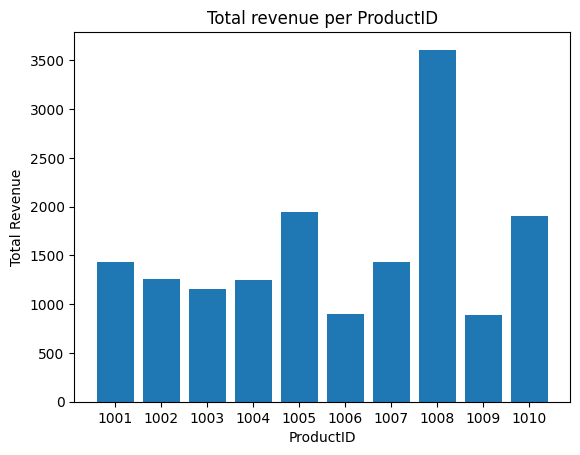

In [98]:
import matplotlib.pyplot as plt

plt.bar(grouped_df.index,grouped_df["TotalSale"])
plt.xticks(grouped_df.index)
plt.title("Total revenue per ProductID")
plt.xlabel("ProductID")
plt.ylabel("Total Revenue")
plt.show()

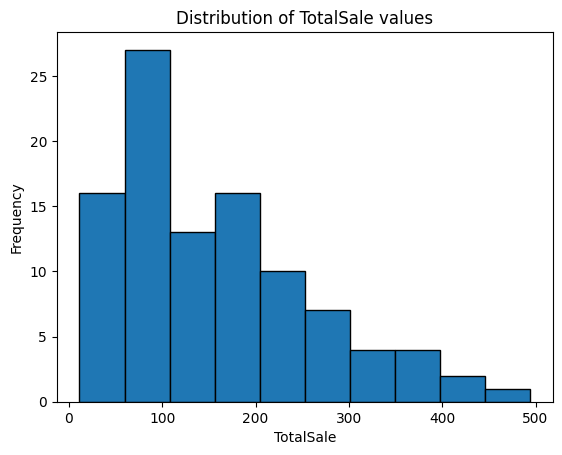

In [99]:
plt.hist(sales_df["TotalSale"],bins=10,edgecolor="black")
plt.title("Distribution of TotalSale values")
plt.xlabel("TotalSale")
plt.ylabel("Frequency")
plt.show()

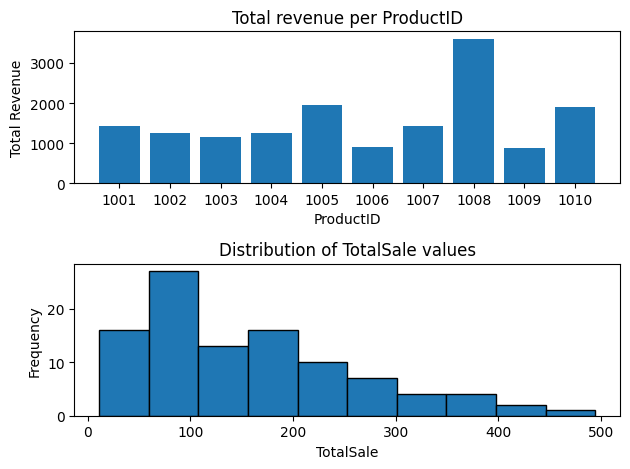

In [103]:
plt.subplot(2,1,1)
plt.bar(grouped_df.index,grouped_df["TotalSale"])
plt.xticks(grouped_df.index)
plt.title("Total revenue per ProductID")
plt.xlabel("ProductID")
plt.ylabel("Total Revenue")

plt.subplot(2,1,2)
plt.hist(sales_df["TotalSale"],bins=10,edgecolor="black")
plt.title("Distribution of TotalSale values")
plt.xlabel("TotalSale")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()